# OpenMC transport model for the annular heavy-water reactor

This notebook turns the annular-core geometry from `theory/reactor_model_theory.tex` into a 3D OpenMC model.

Modeling choices in this notebook:
- preserve the calibrated annular dimensions, axial reflector slabs, and top-inserted central rod
- replace the one-group diffusion solve with continuous-energy Monte Carlo transport
- keep the fuel region homogenized, because the theory model is calibrated at the annulus level rather than with explicit pins

The OpenMC results will not match the one-group diffusion `k_eff` exactly.
That difference is expected: transport uses richer material physics and angular treatment than the calibration solve.

In [2]:
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import openmc

# Core dimensions taken directly from theory/reactor_model_theory.tex and calibration.py
GEOMETRY = {
    "r_inner_cm": 80.0,
    "r_fuel_cm": 345.62,
    "r_refl_cm": 405.62,
    "h_active_cm": 691.2,
    "h_refl_cm": 60.0,
    "r_rod_cm": 50.0,
    "fuel_volume_fraction": 0.0177,
}
GEOMETRY["h_total_cm"] = GEOMETRY["h_active_cm"] + 2.0 * GEOMETRY["h_refl_cm"]

RUNS_ROOT = Path("build/annular")
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

for pattern in (
    "materials.xml",
    "geometry.xml",
    "settings.xml",
    "plots.xml",
    "tallies.xml",
    "model.xml",
    "summary.h5",
    "statepoint.*.h5",
    "volume_*.h5",
):
    for path in Path(".").glob(pattern):
        if path.is_file():
            path.unlink()

def make_run_dir(label, rod_insertion):
    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    run_dir = RUNS_ROOT / f"{label}_rod{rod_insertion:05.3f}_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir

GEOMETRY

{'r_inner_cm': 80.0,
 'r_fuel_cm': 345.62,
 'r_refl_cm': 405.62,
 'h_active_cm': 691.2,
 'h_refl_cm': 60.0,
 'r_rod_cm': 50.0,
 'fuel_volume_fraction': 0.0177,
 'h_total_cm': 811.2}

In [18]:
def make_materials(fuel_fraction):
    natural_uranium = openmc.Material(name="Natural uranium metal")
    natural_uranium.set_density("g/cm3", 19.05)
    natural_uranium.add_element("U", 1.0)
    natural_uranium.temperature = 600.0

    heavy_water = openmc.Material(name="Heavy water moderator")
    heavy_water.set_density("g/cm3", 1.105)
    heavy_water.add_nuclide("H2", 2.0)
    heavy_water.add_nuclide("O16", 1.0)
    heavy_water.add_s_alpha_beta("c_D_in_D2O")
    heavy_water.temperature = 300.0

    lattice_moderator = openmc.Material(name="Heavy water in fuel lattice")
    lattice_moderator.set_density("g/cm3", 1.105)
    lattice_moderator.add_nuclide("H2", 2.0)
    lattice_moderator.add_nuclide("O16", 1.0)
    lattice_moderator.temperature = 300.0

    fuel_annulus = openmc.Material.mix_materials(
        [natural_uranium, lattice_moderator],
        [fuel_fraction, 1.0 - fuel_fraction],
        "vo",
    )
    fuel_annulus.name = "Homogenized annular fuel"
    fuel_annulus.temperature = 600.0

    outer_reflector = heavy_water.clone()
    outer_reflector.name = "Outer heavy water reflector"

    control_rod = openmc.Material(name="B4C control rod")
    control_rod.set_density("g/cm3", 2.52)
    control_rod.add_nuclide("B10", 3.8)
    control_rod.add_nuclide("B11", 0.2)
    control_rod.add_element("C", 1.0)
    control_rod.temperature = 300.0

    beryllium = openmc.Material(name="Beryllium")
    beryllium.set_density("g/cm3", 3.01)
    beryllium.add_element("Be", 1.0)
    beryllium.add_element("O", 1.0) # now its oxide, not pure metal
    beryllium.temperature = 300.0

    materials = openmc.Materials([natural_uranium, fuel_annulus, heavy_water, outer_reflector, control_rod, beryllium])
    return materials, {
        "natural_uranium": natural_uranium,
        "lattice_moderator": lattice_moderator,
        "fuel_annulus": fuel_annulus,
        "inner_moderator": heavy_water,
        "outer_reflector": outer_reflector,
        "control_rod": control_rod,
        "beryllium": beryllium
    }

materials, material_map = make_materials(GEOMETRY["fuel_volume_fraction"])
materials

[Material
 	ID             =	37
 	Name           =	Natural uranium metal
 	Temperature    =	600.0
 	Density        =	19.05 [g/cm3]
 	Volume         =	None [cm^3]
 	Depletable     =	True
 	S(a,b) Tables  
 	Nuclides       
 	U234           =	5.4e-05      [ao]
 	U235           =	0.007204     [ao]
 	U238           =	0.992742     [ao],
 Material
 	ID             =	40
 	Name           =	Homogenized annular fuel
 	Temperature    =	600.0
 	Density        =	1.4226264999999998 [g/cm3]
 	Volume         =	None [cm^3]
 	Depletable     =	True
 	S(a,b) Tables  
 	Nuclides       
 	U234           =	4.6630470422650016e-07 [ao]
 	U235           =	6.220850165273533e-05 [ao]
 	U238           =	0.008572597494133784 [ao]
 	H2             =	0.6609098184663396 [ao]
 	O16            =	0.3304549092331698 [ao],
 Material
 	ID             =	38
 	Name           =	Heavy water moderator
 	Temperature    =	300.0
 	Density        =	1.105 [g/cm3]
 	Volume         =	None [cm^3]
 	Depletable     =	False
 	S(a,b) Tables 

In [20]:
def build_model(rod_insertion=0.0, fuel_fraction=None, particles=12000, batches=100, inactive=20):
    fuel_fraction = GEOMETRY["fuel_volume_fraction"] if fuel_fraction is None else fuel_fraction
    rod_insertion = float(np.clip(rod_insertion, 0.0, 1.0))
    materials, material_map = make_materials(fuel_fraction)

    active_half = 0.5 * GEOMETRY["h_active_cm"]
    total_half = 0.5 * GEOMETRY["h_total_cm"]
    rod_tip_z_cm = total_half - rod_insertion * GEOMETRY["h_active_cm"]

    rod_cyl = openmc.ZCylinder(r=GEOMETRY["r_rod_cm"])
    inner_cyl = openmc.ZCylinder(r=GEOMETRY["r_inner_cm"])
    fuel_cyl = openmc.ZCylinder(r=GEOMETRY["r_fuel_cm"])
    refl_cyl = openmc.ZCylinder(r=GEOMETRY["r_refl_cm"], boundary_type="vacuum")

    z_bottom = openmc.ZPlane(z0=-total_half, boundary_type="vacuum")
    z_top = openmc.ZPlane(z0=total_half, boundary_type="vacuum")
    z_active_bottom = openmc.ZPlane(z0=-active_half)
    z_active_top = openmc.ZPlane(z0=active_half)
    z_rod_tip = openmc.ZPlane(z0=rod_tip_z_cm)

    rod_region = -rod_cyl & +z_rod_tip & -z_top
    central_moderator_region = -rod_cyl & +z_bottom & -z_rod_tip
    inner_moderator_region = +rod_cyl & -inner_cyl & +z_bottom & -z_top
    fuel_region = +inner_cyl & -fuel_cyl & +z_active_bottom & -z_active_top
    upper_reflector_region = +inner_cyl & -fuel_cyl & +z_active_top & -z_top
    lower_reflector_region = +inner_cyl & -fuel_cyl & +z_bottom & -z_active_bottom
    outer_reflector_region = +fuel_cyl & -refl_cyl & +z_bottom & -z_top

    cells = [
        openmc.Cell(name="control_rod", fill=material_map["control_rod"], region=rod_region),
        openmc.Cell(name="central_moderator", fill=material_map["inner_moderator"], region=central_moderator_region),
        openmc.Cell(name="inner_moderator_annulus", fill=material_map["inner_moderator"], region=inner_moderator_region),
        openmc.Cell(name="fuel_annulus", fill=material_map["fuel_annulus"], region=fuel_region),
        openmc.Cell(name="upper_axial_reflector", fill=material_map["outer_reflector"], region=upper_reflector_region),
        openmc.Cell(name="lower_axial_reflector", fill=material_map["outer_reflector"], region=lower_reflector_region),
        openmc.Cell(name="outer_reflector", fill=material_map["outer_reflector"], region=outer_reflector_region),
    ]

    geometry = openmc.Geometry(openmc.Universe(cells=cells))

    source = openmc.IndependentSource(
        space=openmc.stats.Box(
            (-GEOMETRY["r_fuel_cm"], -GEOMETRY["r_fuel_cm"], -active_half),
            (GEOMETRY["r_fuel_cm"], GEOMETRY["r_fuel_cm"], active_half),
        ),
        constraints={"fissionable": True},
    )

    settings = openmc.Settings()
    settings.run_mode = "eigenvalue"
    settings.particles = particles
    settings.batches = batches
    settings.inactive = inactive
    settings.source = source
    settings.temperature = {"method": "interpolation"}

    mesh = openmc.RegularMesh()
    mesh.dimension = (180, 1, 180)
    mesh.lower_left = (-GEOMETRY["r_refl_cm"], -1.0, -total_half)
    mesh.upper_right = (GEOMETRY["r_refl_cm"], 1.0, total_half)

    tally = openmc.Tally(name="core-mesh")
    tally.filters = [openmc.MeshFilter(mesh)]
    tally.scores = ["flux", "fission", "nu-fission"]
    tallies = openmc.Tallies([tally])

    xy_plot = openmc.Plot()
    xy_plot.filename = f"annular_core_xy_{int(100 * rod_insertion):03d}"
    xy_plot.origin = (0.0, 0.0, 0.0)
    xy_plot.width = (2.0 * GEOMETRY["r_refl_cm"], 2.0 * GEOMETRY["r_refl_cm"])
    xy_plot.pixels = (700, 700)
    xy_plot.basis = "xy"
    xy_plot.color_by = "material"

    xz_plot = openmc.Plot()
    xz_plot.filename = f"annular_core_xz_{int(100 * rod_insertion):03d}"
    xz_plot.origin = (0.0, 0.0, 0.0)
    xz_plot.width = (2.0 * GEOMETRY["r_refl_cm"], GEOMETRY["h_total_cm"])
    xz_plot.pixels = (900, 900)
    xz_plot.basis = "xz"
    xz_plot.color_by = "material"

    model = openmc.Model(geometry=geometry, materials=materials, settings=settings, tallies=tallies)
    model.plots = openmc.Plots([xy_plot, xz_plot])
    return model, rod_tip_z_cm

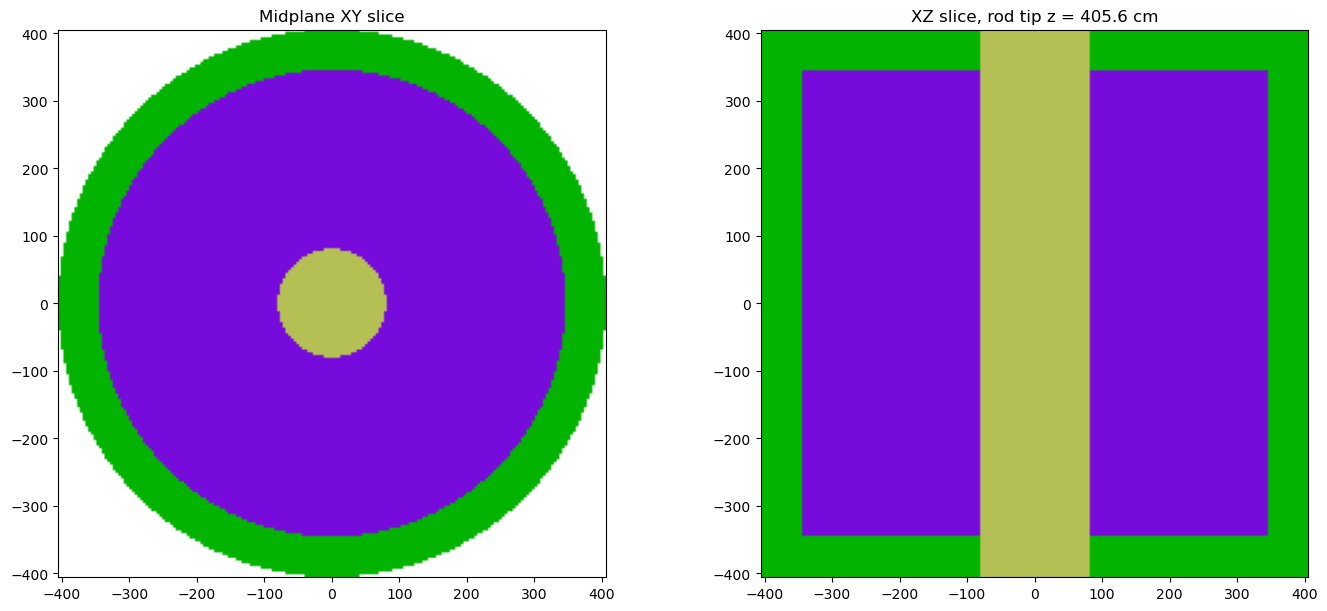

In [7]:
preview_model, preview_tip = build_model(rod_insertion=0.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(2.0 * GEOMETRY["r_refl_cm"], 2.0 * GEOMETRY["r_refl_cm"]),
    basis="xy",
    color_by="material",
    axes=axes[0],
)
axes[0].set_title("Midplane XY slice")

preview_model.geometry.root_universe.plot(
    origin=(0.0, 0.0, 0.0),
    width=(2.0 * GEOMETRY["r_refl_cm"], GEOMETRY["h_total_cm"]),
    basis="xz",
    color_by="material",
    axes=axes[1],
)
axes[1].set_title(f"XZ slice, rod tip z = {preview_tip:.1f} cm")
plt.show()

In [22]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.001
    reference_model, _ = build_model(
        rod_insertion=reference_insertion,
        particles=16000,
        batches=50,
        inactive=30,
    )
    run_dir = make_run_dir("reference", reference_insertion)
    statepoint_path = Path(reference_model.run(cwd=run_dir))
    if not statepoint_path.is_absolute():
        statepoint_path = run_dir / statepoint_path
    print(f"Run directory: {run_dir}")
    print(f"OpenMC run finished: {statepoint_path}")
else:
    # run_dir = None
    # statepoint_path = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

k_eff = 0.977502 +/- 0.001262
reactivity = -2301.5 pcm


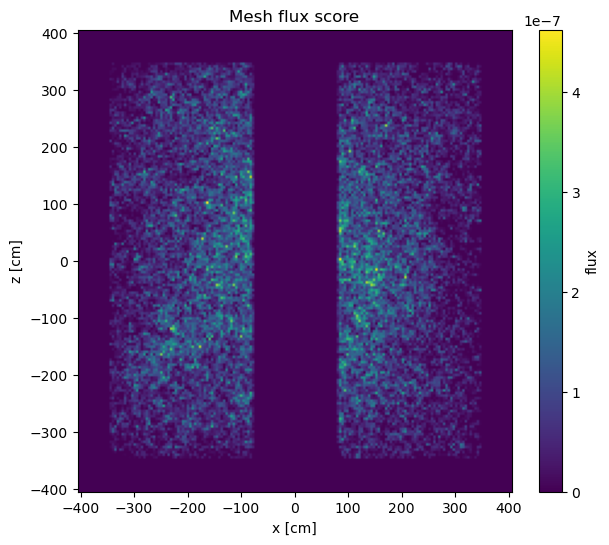

In [9]:
if statepoint_path is not None:
    with openmc.StatePoint(statepoint_path) as statepoint:
        keff = statepoint.keff
        rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
        print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
        print(f"reactivity = {rho_pcm:.1f} pcm")

        mesh_tally = statepoint.get_tally(name="core-mesh")
        flux_tally = mesh_tally.get_slice(scores=["fission"])
        mesh_shape = tuple(mesh_tally.filters[0].mesh.dimension)
        flux = flux_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()

        plt.figure(figsize=(7, 6))
        plt.imshow(
            flux,
            origin="lower",
            aspect="auto",
            extent=[
                -GEOMETRY["r_refl_cm"],
                GEOMETRY["r_refl_cm"],
                -0.5 * GEOMETRY["h_total_cm"],
                0.5 * GEOMETRY["h_total_cm"],
            ],
        )
        plt.xlabel("x [cm]")
        plt.ylabel("z [cm]")
        plt.title("Mesh flux score")
        plt.colorbar(label="flux")
        plt.show()
else:
    print("Run the previous cell after configuring OpenMC nuclear data to get k_eff and a flux map.")

With k_eff < 1 we see that the Monte Carlo code gives us a more accurate description of our annular core reactor. Using the power of OpenMC, we will now model a more realistic natural uranium core that doesn't use a homogeneous core but a hetereogenous mixture of uranium and heavy water. To get in the right ball park, we have to know what fuel fraction is needed.

In [30]:
fuel_volume_fraction = 0.007
materials, material_map = make_materials(fuel_volume_fraction)

reference_insertion = 0.001
reference_model, _ = build_model(
    rod_insertion=reference_insertion,
    fuel_fraction=fuel_volume_fraction,
    particles=16000,
    batches=10,
    inactive=3,
)
run_dir = make_run_dir("ff:"+str(fuel_volume_fraction), reference_insertion)
statepoint_path = Path(reference_model.run(cwd=run_dir))
if not statepoint_path.is_absolute():
    statepoint_path = run_dir / statepoint_path
print(f"Run directory: {run_dir}")
print(f"OpenMC run finished: {statepoint_path}")


                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

k_eff = 1.036431 +/- 0.004673
reactivity = 3515.0 pcm


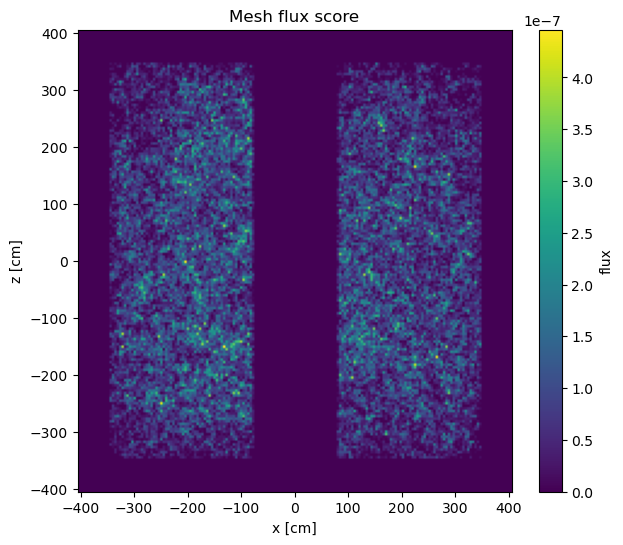

: 

In [ ]:
with openmc.StatePoint(statepoint_path) as statepoint:
    keff = statepoint.keff
    rho_pcm = (keff.n - 1.0) / keff.n * 1.0e5
    print(f"k_eff = {keff.n:.6f} +/- {keff.s:.6f}")
    print(f"reactivity = {rho_pcm:.1f} pcm")

    mesh_tally = statepoint.get_tally(name="core-mesh")
    flux_tally = mesh_tally.get_slice(scores=["fission"])
    mesh_shape = tuple(mesh_tally.filters[0].mesh.dimension)
    flux = flux_tally.get_reshaped_data(value="mean").reshape(mesh_shape).squeeze()

    plt.figure(figsize=(7, 6))
    plt.imshow(
        flux,
        origin="lower",
        aspect="auto",
        extent=[
            -GEOMETRY["r_refl_cm"],
            GEOMETRY["r_refl_cm"],
            -0.5 * GEOMETRY["h_total_cm"],
            0.5 * GEOMETRY["h_total_cm"],
        ],
    )
    plt.xlabel("x [cm]")
    plt.ylabel("z [cm]")
    plt.title("Mesh flux score")
    plt.colorbar(label="flux")
    plt.show()